# Part 4 — DQN Training (Local)
**Optimization 2 · Project 3 · Connect-4**

### How to use
1. Set `TEST_MODE = True` for a quick 200 episode verification run
2. If test looks good, set `TEST_MODE = False` and run overnight
3. All files load automatically from your Downloads folder
4. Checkpoints save locally every 500 episodes so you never lose progress

In [2]:
# ── TEST MODE SWITCH ───────────────────────────────────────────────────────
# Set to True for a quick 200 episode test to verify everything works
# Set to False for the full overnight run

TEST_MODE = False   # ← flip to False for full run

In [18]:
# ── Step 1: Verify installs ────────────────────────────────────────────────
import tensorflow as tf
import torch
print('TF version:', tf.__version__)
print('PyTorch version:', torch.__version__)
print('TEST_MODE:', TEST_MODE)

TF version: 2.21.0
PyTorch version: 2.9.0+cu126
TEST_MODE: False


In [3]:
# ── Step 2: Hyperparameters ────────────────────────────────────────────────
import os

# Paths — all files load from Downloads
# Paths — all files load from Downloads
DOWNLOADS      = r'C:\Users\prisc\Downloads'
CHECKPOINT_DIR = r'C:\Users\prisc\Downloads\Connect4_DQN\checkpoints'
BEST_MODEL_DIR = r'C:\Users\prisc\Downloads\Connect4_DQN\best_model'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(BEST_MODEL_DIR, exist_ok=True)

# Hyperparameters — auto switch between test and full run
if TEST_MODE:
    N_EPISODES          = 200
    EVAL_EVERY          = 20
    REPLAY_BUFFER_SIZE  = 2000
    MIN_BUFFER_SIZE     = 200
    EPSILON_DECAY_STEPS = 5000
    ADD_TO_POOL_EVERY   = 50
    CHECKPOINT_EVERY    = 100
    print('Running in TEST MODE — 200 episodes')
else:
    N_EPISODES          = 5000
    EVAL_EVERY          = 100
    REPLAY_BUFFER_SIZE  = 50000
    MIN_BUFFER_SIZE     = 1000
    EPSILON_DECAY_STEPS = 75000
    ADD_TO_POOL_EVERY   = 200
    CHECKPOINT_EVERY    = 500
    print('Running in FULL MODE — 5000 episodes')

GAMMA               = 0.99
LR                  = 1e-4
BATCH_SIZE          = 64
TARGET_UPDATE_EVERY = 1000
EPSILON_START       = 1.0
EPSILON_END         = 0.05
RANDOM_INIT_MOVES   = 4
TRAIN_EVERY         = 4
MAX_OWN_SNAPSHOTS   = 6
EVAL_GAMES          = 100
FIXED_POOL_SIZE     = 7

print(f'Episodes: {N_EPISODES}, Eval every: {EVAL_EVERY}')

Running in FULL MODE — 5000 episodes
Episodes: 5000, Eval every: 100


In [4]:
# ── Step 3: Imports ────────────────────────────────────────────────────────
import sys, random, collections
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch
import torch.nn as nn
import torch.nn.functional as F

# Add Downloads to path so connect4_env and loader import correctly
sys.path.insert(0, DOWNLOADS)

from connect4_env import (
    encode_board, legal_moves, game_over, make_board, step,
    ModelAgent, RandomAgent, StrongRuleAgent, evaluate_agents,
    find_winning_move
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('Imports OK')

Imports OK


In [5]:
# ── Step 4: Load PyTorch models ────────────────────────────────────────────

# ── Prisca CNN ──
class Connect4CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1    = nn.Conv2d(2, 64,  kernel_size=3, padding=1)
        self.conv2    = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3    = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.fc1      = nn.Linear(256 * 6 * 7, 256)
        self.fc2      = nn.Linear(256, 128)
        self.fc_out   = nn.Linear(128, 7)
        self.dropout1 = nn.Dropout(0.4)
        self.dropout2 = nn.Dropout(0.3)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc_out(x)
        x = torch.clamp(x, -10, 10)
        return F.softmax(x, dim=1)

# ── Emily CNN ──
class EmilyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(2,   64,  kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64,  128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.fc1   = nn.Linear(512, 1024)
        self.fc2   = nn.Linear(1024, 7)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = x.mean(dim=[2, 3])   # global average pooling
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# ── Transformer ──
class Connect4Transformer(nn.Module):
    def __init__(self, num_patches=42, patch_size=2, hidden_dim=128,
                 num_layers=6, num_heads=8, mlp_dim=256,
                 dropout_rate=0.3, num_classes=7):
        super().__init__()
        self.patch_embedding = nn.Linear(patch_size, hidden_dim)
        self.row_embedding   = nn.Embedding(6, hidden_dim // 2)
        self.col_embedding   = nn.Embedding(7, hidden_dim // 2)
        self.class_token     = nn.Parameter(torch.randn(1, 1, hidden_dim))
        enc_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=num_heads, dim_feedforward=mlp_dim,
            dropout=dropout_rate, activation='gelu',
            batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(hidden_dim)
        self.head = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embedding(x)
        ri = torch.arange(6, device=x.device).repeat_interleave(7)
        ci = torch.arange(7, device=x.device).repeat(6)
        pos = torch.cat([self.row_embedding(ri), self.col_embedding(ci)], dim=-1)
        x = x + pos.unsqueeze(0)
        x = torch.cat([self.class_token.expand(B, -1, -1), x], dim=1)
        x = self.transformer(x)
        return self.head(self.norm(x[:, 0]))


# ── Agent wrapper for PyTorch CNNs ──
class CNNAgent:
    def __init__(self, model, channels_first=True, strong=True):
        self.model          = model.cpu().eval()
        self.channels_first = channels_first
        self.strong         = strong

    def select_move(self, board, player):
        if self.strong:
            col = find_winning_move(board, player)
            if col is not None: return col
            col = find_winning_move(board, -player)
            if col is not None: return col
        legal = legal_moves(board)
        if self.channels_first:
            enc = np.zeros((2, 6, 7), dtype=np.float32)
            enc[0] = (board == player)
            enc[1] = (board == -player)
        else:
            enc = np.zeros((6, 7, 2), dtype=np.float32)
            enc[:, :, 0] = (board == player)
            enc[:, :, 1] = (board == -player)
        inp = torch.tensor(enc).unsqueeze(0).cpu()
        with torch.no_grad():
            out = self.model(inp)[0].numpy()
        mask = np.full(7, -1e9); mask[legal] = 0.0
        return int(np.argmax(out + mask))


# ── Agent wrapper for Transformer ──
class TransformerAgent:
    def __init__(self, model, strong=True):
        self.model  = model.cpu().eval()
        self.strong = strong

    def select_move(self, board, player):
        if self.strong:
            col = find_winning_move(board, player)
            if col is not None: return col
            col = find_winning_move(board, -player)
            if col is not None: return col
        legal = legal_moves(board)
        enc = np.zeros((6, 7, 2), dtype=np.float32)
        enc[:, :, 0] = (board == player)
        enc[:, :, 1] = (board == -player)
        patches = torch.tensor(enc.reshape(1, 42, 2)).cpu()
        with torch.no_grad():
            logits = self.model(patches)[0].numpy()
        mask = np.full(7, -1e9); mask[legal] = 0.0
        return int(np.argmax(logits + mask))


# Load all PyTorch models
prisca_model = Connect4CNN()
prisca_sd    = torch.load(
    os.path.join(DOWNLOADS, 'connect4_cnn (1).pt'),
    map_location='cpu', weights_only=True
)
prisca_model.load_state_dict(prisca_sd)
prisca_agent = CNNAgent(prisca_model, channels_first=True, strong=True)
print('Prisca CNN loaded OK.')

emily_model = EmilyCNN()
emily_sd    = torch.load(
    os.path.join(DOWNLOADS, 'emily_cnn.pt'),
    map_location='cpu', weights_only=False
)
if not isinstance(emily_sd, dict):
    emily_sd = emily_sd.state_dict()
emily_model.load_state_dict(emily_sd)
emily_agent = CNNAgent(emily_model, channels_first=True, strong=True)
print('Emily CNN loaded OK.')

transformer_model = torch.load(
    os.path.join(DOWNLOADS, 'connect4_transformer (1).pt'),
    map_location='cpu', weights_only=False
)
transformer_model.eval()
transformer_agent = TransformerAgent(transformer_model, strong=True)
print('Transformer loaded OK.')

Prisca CNN loaded OK.
Emily CNN loaded OK.
Transformer loaded OK.


In [6]:
# ── Step 5: Load Keras models ──────────────────────────────────────────────
import importlib.util

# Load loader.py directly to avoid folder name conflict
spec = importlib.util.spec_from_file_location(
    'loader', os.path.join(DOWNLOADS, 'loader.py')
)
loader = importlib.util.module_from_spec(spec)
spec.loader.exec_module(loader)
load_agent = loader.load_agent

# Tell loader where models folder is
import shutil, pathlib
models_dir = os.path.join(DOWNLOADS, 'models')
os.makedirs(models_dir, exist_ok=True)

# Copy model files into models/ subfolder so loader can find them
for src, dst in [
    ('josh_cnn.h5',    'josh_cnn.h5'),
    ('abhay_cnn.keras','abhay_cnn.keras'),
]:
    src_path = os.path.join(DOWNLOADS, src)
    dst_path = os.path.join(models_dir, dst)
    if os.path.exists(src_path) and not os.path.exists(dst_path):
        shutil.copy(src_path, dst_path)

josh_agent  = load_agent('josh_cnn')
abhay_agent = load_agent('abhay_cnn')
print('Josh CNN loaded OK.')
print('Abhay CNN loaded OK.')

# Load PG model
pg_model = keras.models.load_model(
    os.path.join(DOWNLOADS, 'm1_pg_final.keras'), compile=False
)
pg_agent = ModelAgent(pg_model, sample=False, strong=True)
print('PG model loaded OK.')

Josh CNN loaded OK.
Abhay CNN loaded OK.
PG model loaded OK.


In [7]:
# ── Step 6: Build DQN ──────────────────────────────────────────────────────
# Same architecture as PG network but with tanh output (as per assignment)

def build_dqn():
    inp = keras.Input(shape=(6, 7, 2))
    x   = layers.Conv2D(64,  3, padding='same', activation='relu')(inp)
    x   = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x   = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x   = layers.Flatten()(x)
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(7, activation='tanh', name='q_values')(x)
    return keras.Model(inp, out, name='Connect4DQN')

dqn_online = build_dqn()
dqn_target = build_dqn()
dqn_target.set_weights(dqn_online.get_weights())
optimizer  = keras.optimizers.Adam(learning_rate=LR)

print('DQN built.')
dqn_online.summary()

DQN built.


Model: "Connect4DQN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6, 7, 2)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 6, 7, 64)       │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 6, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5376)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,376,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_values (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,632,967 (6.23 MB)

 Trainable params: 1,632,967 (6.23 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# ── Step 7: Replay Buffer ──────────────────────────────────────────────────

class ReplayBuffer:
    def __init__(self, maxlen=REPLAY_BUFFER_SIZE):
        self.buf = collections.deque(maxlen=maxlen)

    def add(self, s, a, r, s2, done):
        self.buf.append((s, a, r, s2, done))

    def sample(self, n=BATCH_SIZE):
        batch = random.sample(self.buf, n)
        s, a, r, s2, d = zip(*batch)
        return (np.array(s,  dtype=np.float32),
                np.array(a,  dtype=np.int32),
                np.array(r,  dtype=np.float32),
                np.array(s2, dtype=np.float32),
                np.array(d,  dtype=np.float32))

    def __len__(self): return len(self.buf)

replay_buffer = ReplayBuffer()
print('Replay buffer ready.')

Replay buffer ready.


In [9]:
# ── Step 8: Opponent pool ──────────────────────────────────────────────────
# First FIXED_POOL_SIZE entries are NEVER removed.

def _keras_agent(model):
    return ModelAgent(model, sample=True, strong=True)

FIXED_POOL_SIZE = 8
opponent_pool = [
    RandomAgent(),          # 0 - Josh's built-in random agent
    StrongRuleAgent(),      # 1 - Josh's built-in rule agent
    josh_agent,             # 2 - Josh's CNN
    abhay_agent,            # 3 - Abhay's CNN
    prisca_agent,           # 4 - Prisca's CNN
    emily_agent,            # 5 - Emily's CNN
    transformer_agent,      # 6 - Transformer
    pg_agent,               # 7 - PG model from Steps 1-3
]

own_snapshot_count = 0
print(f'Opponent pool size: {len(opponent_pool)}')
print('Pool: Random, Strong, Josh, Abhay, Prisca, Emily, Transformer, PG')

Opponent pool size: 8
Pool: Random, Strong, Josh, Abhay, Prisca, Emily, Transformer, PG


In [10]:
# ── Step 9: Helper functions ───────────────────────────────────────────────

total_steps = 0

def get_epsilon():
    frac = min(total_steps / EPSILON_DECAY_STEPS, 1.0)
    return EPSILON_START + frac * (EPSILON_END - EPSILON_START)

def select_move_dqn(board, player, epsilon):
    legal = legal_moves(board)
    if random.random() < epsilon:
        return random.choice(legal)
    enc   = encode_board(board, player)[np.newaxis].astype(np.float32)
    qvals = dqn_online(enc, training=False).numpy()[0]
    mask  = np.full(7, -1e9); mask[legal] = 0.0
    return int(np.argmax(qvals + mask))

@tf.function
def train_step(states, actions, rewards, next_states, dones):
    """Bellman update: target = r + gamma * max Q_target(s') * (1-done)"""
    max_next = tf.reduce_max(dqn_target(next_states, training=False), axis=1)
    targets  = rewards + GAMMA * max_next * (1.0 - dones)
    with tf.GradientTape() as tape:
        qvals    = dqn_online(states, training=True)
        indices  = tf.stack([tf.range(BATCH_SIZE, dtype=tf.int32), actions], axis=1)
        chosen_q = tf.gather_nd(qvals, indices)
        loss     = tf.reduce_mean(tf.square(targets - chosen_q))
    grads, _ = tf.clip_by_global_norm(
        tape.gradient(loss, dqn_online.trainable_variables), 1.0)
    optimizer.apply_gradients(zip(grads, dqn_online.trainable_variables))
    return loss

def sync_target():
    dqn_target.set_weights(dqn_online.get_weights())

def play_episode(m2_agent, epsilon):
    """
    Fixed version — next_state is captured AFTER opponent responds,
    as specified in the assignment: next state is the board on YOUR
    next turn, NOT the opponent's turn.
    """
    global total_steps
    dqn_player = random.choice([1, -1])
    board      = make_board()
    current    = 1

    # Random warm-start moves (not recorded in buffer)
    for _ in range(RANDOM_INIT_MOVES):
        cols = legal_moves(board)
        if not cols: break
        board, _ = step(board, np.random.choice(cols), current)
        done, winner = game_over(board)
        if done: return winner
        current = -current

    # Always start main loop on DQN's turn
    # Advance to DQN's turn if needed
    if current != dqn_player:
        cols = legal_moves(board)
        if not cols: return 0
        col = m2_agent.select_move(board, current)
        board, _ = step(board, col, current)
        done, winner = game_over(board)
        if done: return winner
        current = dqn_player

    while True:
        # ── DQN's turn ──
        cols = legal_moves(board)
        if not cols: return 0

        state = encode_board(board, dqn_player).astype(np.float32)
        col   = select_move_dqn(board, dqn_player, epsilon)
        total_steps += 1
        board, _ = step(board, col, dqn_player)
        done, winner = game_over(board)

        if done:
            # Game over right after DQN moves
            reward     = 1.0 if winner == dqn_player else (0.1 if winner == 0 else -1.0)
            next_state = encode_board(board, dqn_player).astype(np.float32)
            replay_buffer.add(state, col, reward, next_state, True)
            return winner

        # ── Opponent's turn ──
        opp_cols = legal_moves(board)
        if not opp_cols:
            # Draw after DQN move, before opponent
            next_state = encode_board(board, dqn_player).astype(np.float32)
            replay_buffer.add(state, col, 0.1, next_state, True)
            return 0

        opp_col = m2_agent.select_move(board, -dqn_player)
        board, _ = step(board, opp_col, -dqn_player)
        done, winner = game_over(board)

        # NOW record transition — next_state is after opponent replied
        # This is the board on DQN's NEXT turn as required by assignment
        if done:
            reward = -1.0 if winner == -dqn_player else 0.1
        else:
            reward = 0.0
        next_state = encode_board(board, dqn_player).astype(np.float32)
        replay_buffer.add(state, col, reward, next_state, float(done))

        if done: return winner

print('Helpers defined.')
print('play_episode uses FIXED next_state (after opponent responds) ✓')

Helpers defined.
play_episode uses FIXED next_state (after opponent responds) ✓


In [12]:
# ── Resume from checkpoint ─────────────────────────────────────────────────
import os

latest_checkpoint = os.path.join(CHECKPOINT_DIR, 'dqn_ep3500.keras')  # change number

if os.path.exists(latest_checkpoint):
    dqn_online.load_weights(latest_checkpoint)
    dqn_target.set_weights(dqn_online.get_weights())
    START_EPISODE = 3500  # change to match checkpoint + 1
    print(f'Resumed from {latest_checkpoint}')
else:
    START_EPISODE = 1
    print('Starting fresh')

Resumed from C:\Users\prisc\Downloads\Connect4_DQN\checkpoints\dqn_ep3500.keras


In [13]:
# ── Step 10: Training loop ─────────────────────────────────────────────────
log = {
    'loss':           [],
    'vs_strong':      [],
    'vs_random':      [],
    'vs_pg':          [],
    'vs_josh':        [],
    'vs_abhay':       [],
    'vs_prisca':      [],
    'vs_emily':       [],
    'vs_transformer': [],
}
log_iters   = []
log_epsilon = []

# Evaluation agents (argmax, strong rules)
eval_strong      = StrongRuleAgent()
eval_random      = RandomAgent()
eval_pg          = ModelAgent(pg_model,   sample=False, strong=True)
eval_josh        = josh_agent
eval_abhay       = abhay_agent
eval_prisca      = CNNAgent(prisca_model, channels_first=True, strong=True)
eval_emily       = CNNAgent(emily_model,  channels_first=True, strong=True)
eval_transformer = TransformerAgent(transformer_model, strong=True)

own_snapshot_count = 0
loss_accum         = []
best_wr            = 0.0
total_steps        = 0

print(f'Starting DQN training — {N_EPISODES} episodes')
print(f'Evaluating every {EVAL_EVERY} episodes against 8 opponents')
print(f'Checkpoints saving to: {CHECKPOINT_DIR}\n')

for episode in range(START_EPISODE, N_EPISODES + 1):

    epsilon  = get_epsilon()
    m2_agent = random.choice(opponent_pool)
    play_episode(m2_agent, epsilon)

    # Train
    if len(replay_buffer) >= MIN_BUFFER_SIZE and total_steps % TRAIN_EVERY == 0:
        s, a, r, s2, d = replay_buffer.sample()
        loss = train_step(
            tf.constant(s), tf.constant(a), tf.constant(r),
            tf.constant(s2), tf.constant(d)
        )
        loss_accum.append(float(loss))

    # Sync target network
    if total_steps > 0 and total_steps % TARGET_UPDATE_EVERY == 0:
        sync_target()
        if TEST_MODE:
            print(f'  Target network synced at step {total_steps}')

    # Evaluate
    if episode % EVAL_EVERY == 0:
        dqn_eval = ModelAgent(dqn_online, sample=False, strong=True)

        eval_opponents = {
            'vs_strong':      eval_strong,
            'vs_random':      eval_random,
            'vs_pg':          eval_pg,
            'vs_josh':        eval_josh,
            'vs_abhay':       eval_abhay,
            'vs_prisca':      eval_prisca,
            'vs_emily':       eval_emily,
            'vs_transformer': eval_transformer,
        }

        avg_loss = np.mean(loss_accum) if loss_accum else 0.0
        log['loss'].append(avg_loss)
        loss_accum.clear()

        for key, opp in eval_opponents.items():
            wr = evaluate_agents(dqn_eval, opp, n_games=EVAL_GAMES)['win_rate']
            log[key].append(wr)

        log_iters.append(episode)
        log_epsilon.append(epsilon)

        print(f'[ep {episode:>5}] eps={epsilon:.3f} loss={avg_loss:.4f} | '
              f'Strong:{log["vs_strong"][-1]:.0%} '
              f'PG:{log["vs_pg"][-1]:.0%} '
              f'Josh:{log["vs_josh"][-1]:.0%} '
              f'Abhay:{log["vs_abhay"][-1]:.0%} '
              f'Prisca:{log["vs_prisca"][-1]:.0%} '
              f'Emily:{log["vs_emily"][-1]:.0%} '
              f'Trans:{log["vs_transformer"][-1]:.0%} '
              f'Random:{log["vs_random"][-1]:.0%} '
              f'buf={len(replay_buffer)}')

        # Save best model
        if log['vs_strong'][-1] > best_wr:
            best_wr = log['vs_strong'][-1]
            dqn_online.save(os.path.join(BEST_MODEL_DIR, 'dqn_best.keras'))
            print(f'  ★ New best: {best_wr:.1%} vs Strong')

    # Add DQN snapshot to pool
    if episode % ADD_TO_POOL_EVERY == 0:
        snap = build_dqn()
        snap.set_weights(dqn_online.get_weights())
        opponent_pool.append(_keras_agent(snap))
        own_snapshot_count += 1
        if own_snapshot_count > MAX_OWN_SNAPSHOTS:
            opponent_pool.pop(FIXED_POOL_SIZE)
            own_snapshot_count -= 1

    # Save checkpoint
    if episode % CHECKPOINT_EVERY == 0:
        ckpt = os.path.join(CHECKPOINT_DIR, f'dqn_ep{episode}.keras')
        dqn_online.save(ckpt)
        print(f'  Checkpoint saved: dqn_ep{episode}.keras')

print(f'\nTraining complete! Best win rate vs Strong: {best_wr:.1%}')

Starting DQN training — 5000 episodes
Evaluating every 100 episodes against 8 opponents
Checkpoints saving to: C:\Users\prisc\Downloads\Connect4_DQN\checkpoints

[ep  3500] eps=1.000 loss=0.0000 | Strong:61% PG:0% Josh:0% Abhay:0% Prisca:0% Emily:0% Trans:0% Random:100% buf=6
  ★ New best: 61.0% vs Strong
  Checkpoint saved: dqn_ep3500.keras
[ep  3600] eps=0.994 loss=0.0000 | Strong:62% PG:0% Josh:0% Abhay:0% Prisca:0% Emily:0% Trans:0% Random:99% buf=465
  ★ New best: 62.0% vs Strong
[ep  3700] eps=0.988 loss=0.0000 | Strong:61% PG:0% Josh:0% Abhay:0% Prisca:0% Emily:0% Trans:0% Random:99% buf=943
[ep  3800] eps=0.981 loss=0.0721 | Strong:54% PG:0% Josh:0% Abhay:0% Prisca:0% Emily:0% Trans:0% Random:98% buf=1477
[ep  3900] eps=0.974 loss=0.0703 | Strong:60% PG:0% Josh:0% Abhay:0% Prisca:0% Emily:0% Trans:0% Random:100% buf=2020
[ep  4000] eps=0.968 loss=0.0733 | Strong:71% PG:0% Josh:0% Abhay:0% Prisca:0% Emily:0% Trans:0% Random:99% buf=2544
  ★ New best: 71.0% vs Strong
  Checkpoint

In [14]:
# Quick debug
board = make_board()
print('Abhay move:', abhay_agent.select_move(board, 1))
print('Prisca move:', prisca_agent.select_move(board, 1))
print('Emily move:', emily_agent.select_move(board, 1))
print('PG move:', pg_agent.select_move(board, 1))

Abhay move: 3
Prisca move: 3
Emily move: 3
PG move: 3


In [15]:
# ── Step 11: Save final model ──────────────────────────────────────────────
final_path = os.path.join(BEST_MODEL_DIR, 'dqn_final.keras')
dqn_online.save(final_path)
print(f'Final model saved: {final_path}')
print(f'Best model saved:  {os.path.join(BEST_MODEL_DIR, "dqn_best.keras")}')

Final model saved: C:\Users\prisc\Downloads\Connect4_DQN\best_model\dqn_final.keras
Best model saved:  C:\Users\prisc\Downloads\Connect4_DQN\best_model\dqn_best.keras


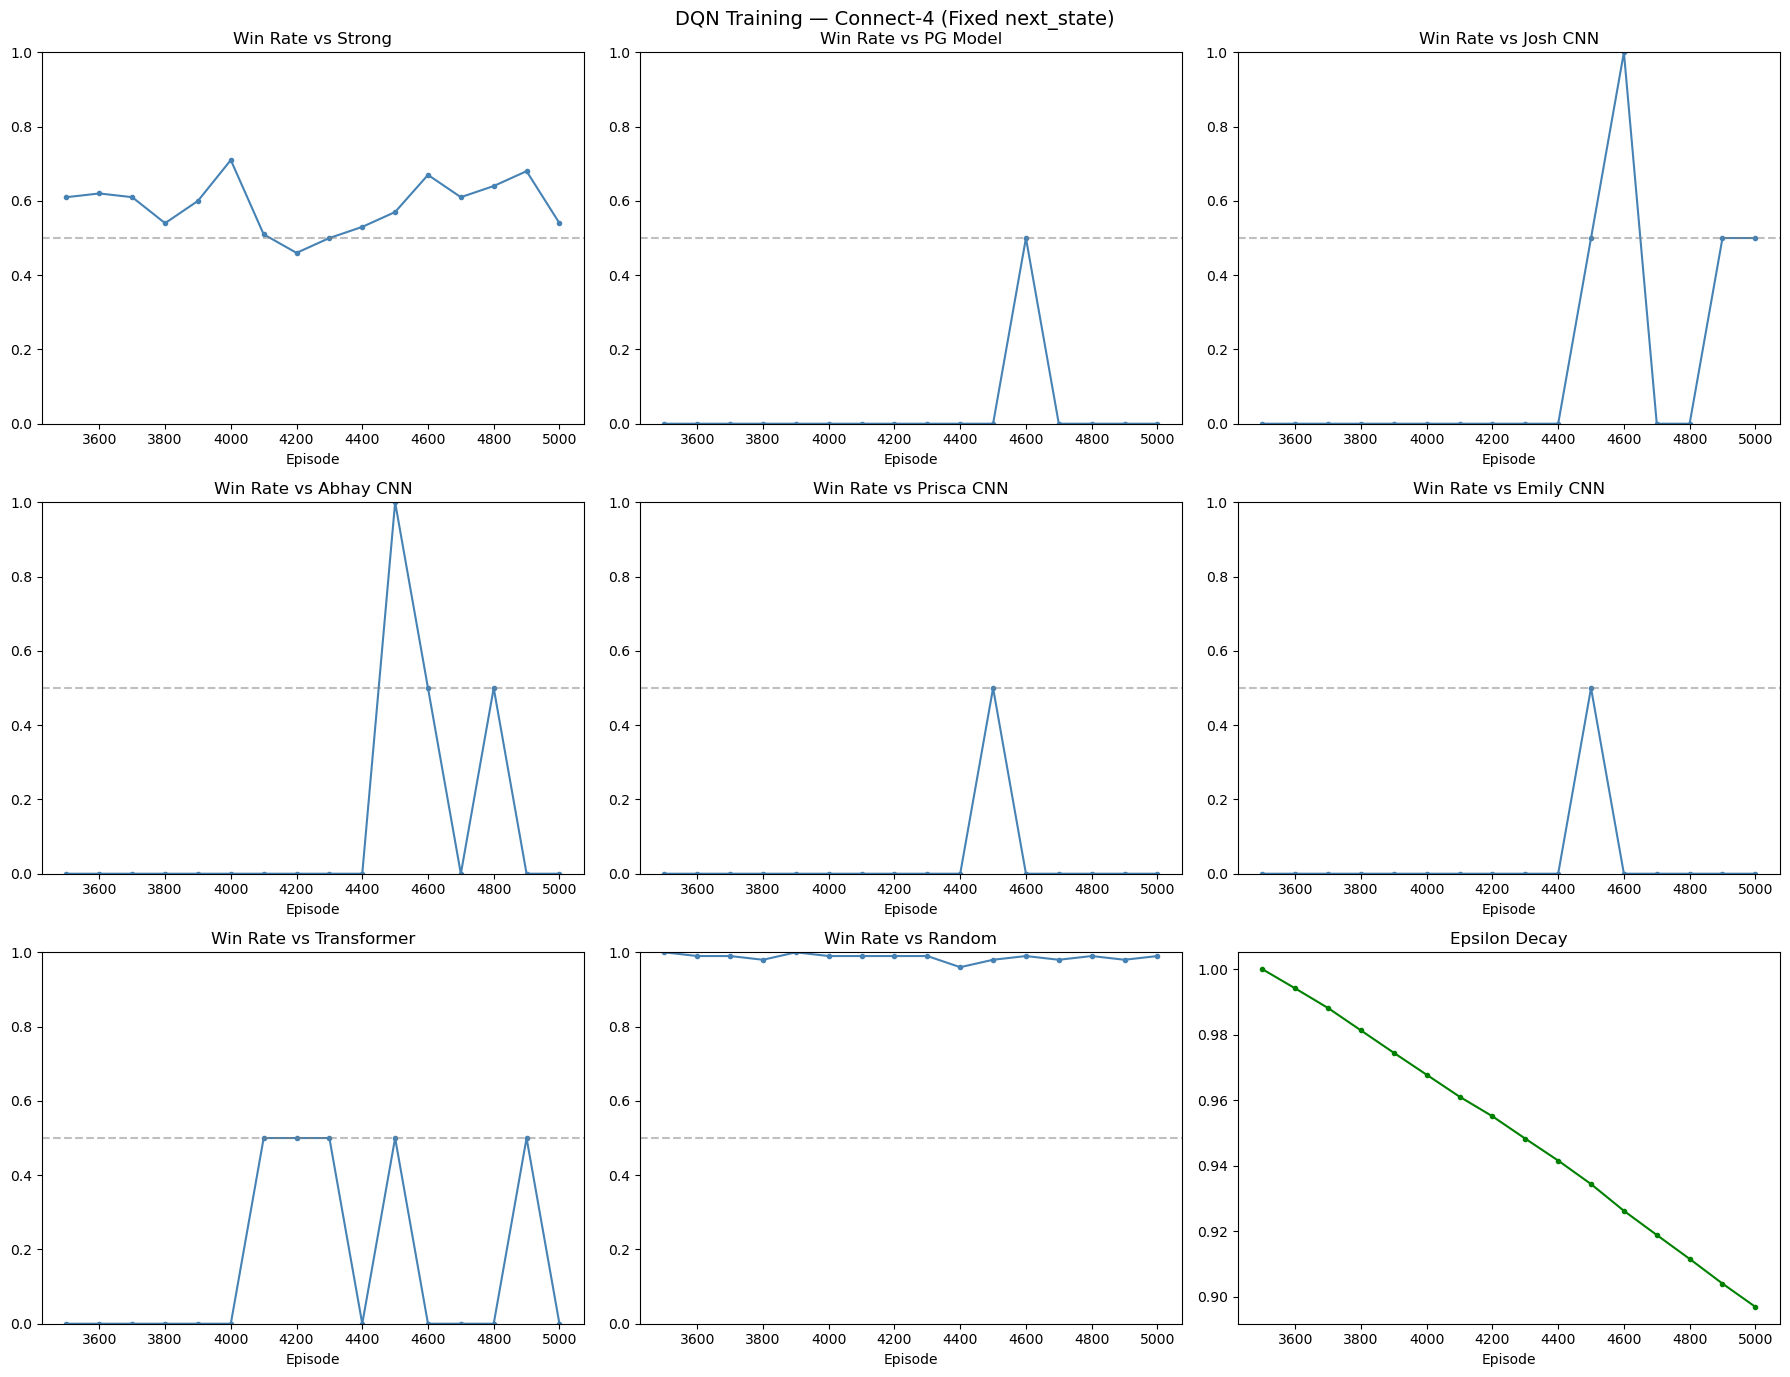

Plot saved: C:\Users\prisc\Downloads\Connect4_DQN\best_model\dqn_training_curves.png


In [16]:
# ── Step 12: Training plots ────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('DQN Training — Connect-4 (Fixed next_state)', fontsize=14)

plot_keys = [
    ('vs_strong',      'Win Rate vs Strong'),
    ('vs_pg',          'Win Rate vs PG Model'),
    ('vs_josh',        'Win Rate vs Josh CNN'),
    ('vs_abhay',       'Win Rate vs Abhay CNN'),
    ('vs_prisca',      'Win Rate vs Prisca CNN'),
    ('vs_emily',       'Win Rate vs Emily CNN'),
    ('vs_transformer', 'Win Rate vs Transformer'),
    ('vs_random',      'Win Rate vs Random'),
    ('loss',           'Training Loss (MSE)'),
]

for idx, (key, title) in enumerate(plot_keys):
    r, c = divmod(idx, 3)
    ax   = axes[r, c]
    ax.plot(log_iters, log[key], marker='o', markersize=3, color='steelblue')
    if key != 'loss':
        ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='50% baseline')
        ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.set_xlabel('Episode')

# Epsilon on last unused slot — replace loss plot position
axes[2, 2].clear()
axes[2, 2].plot(log_iters, log_epsilon, marker='o', markersize=3, color='green')
axes[2, 2].set_title('Epsilon Decay')
axes[2, 2].set_xlabel('Episode')

plt.tight_layout()
plot_path = os.path.join(BEST_MODEL_DIR, 'dqn_training_curves.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Plot saved: {plot_path}')

In [17]:
# ── Step 13: Final results summary ────────────────────────────────────────
print('=== DQN FINAL RESULTS (best win rates) ===')
print(f'{"Opponent":<25} {"Best Win Rate":>15} {"Final Win Rate":>15}')
print('-' * 57)
for key, label in [
    ('vs_strong',      'vs Strong'),
    ('vs_pg',          'vs PG Model'),
    ('vs_josh',        'vs Josh CNN'),
    ('vs_abhay',       'vs Abhay CNN'),
    ('vs_prisca',      'vs Prisca CNN'),
    ('vs_emily',       'vs Emily CNN'),
    ('vs_transformer', 'vs Transformer'),
    ('vs_random',      'vs Random'),
]:
    best  = max(log[key])  if log[key] else 0
    final = log[key][-1]   if log[key] else 0
    print(f'{label:<25} {best:>15.1%} {final:>15.1%}')

print(f'\nBest overall win rate vs Strong: {best_wr:.1%}')
print(f'Models saved to: {BEST_MODEL_DIR}')

=== DQN FINAL RESULTS (best win rates) ===
Opponent                    Best Win Rate  Final Win Rate
---------------------------------------------------------
vs Strong                           71.0%           54.0%
vs PG Model                         50.0%            0.0%
vs Josh CNN                        100.0%           50.0%
vs Abhay CNN                       100.0%            0.0%
vs Prisca CNN                       50.0%            0.0%
vs Emily CNN                        50.0%            0.0%
vs Transformer                      50.0%            0.0%
vs Random                          100.0%           99.0%

Best overall win rate vs Strong: 71.0%
Models saved to: C:\Users\prisc\Downloads\Connect4_DQN\best_model


In [18]:
# ── Post-training evaluation (100 games per opponent) ──────────────────────
print('Running final evaluation — 100 games per opponent...\n')

dqn_eval = ModelAgent(dqn_online, sample=False, strong=True)

final_opponents = {
    'vs Random':      RandomAgent(),
    'vs Strong':      StrongRuleAgent(),
    'vs PG Model':    ModelAgent(pg_model,   sample=False, strong=True),
    'vs Josh CNN':    josh_agent,
    'vs Abhay CNN':   abhay_agent,
    'vs Prisca CNN':  CNNAgent(prisca_model, channels_first=True, strong=True),
    'vs Emily CNN':   CNNAgent(emily_model,  channels_first=True, strong=True),
    'vs Transformer': TransformerAgent(transformer_model, strong=True),
}

print(f'{"Opponent":<20} {"Wins":>6} {"Losses":>8} {"Draws":>7} {"Win Rate":>10}')
print('-' * 55)
for name, opp in final_opponents.items():
    res = evaluate_agents(dqn_eval, opp, n_games=100)
    print(f'{name:<20} {res["wins"]:>6} {res["losses"]:>8} '
          f'{res["draws"]:>7} {res["win_rate"]:>10.1%}')

Running final evaluation — 100 games per opponent...

Opponent               Wins   Losses   Draws   Win Rate
-------------------------------------------------------
vs Random                98        2       0      98.0%
vs Strong                55       41       4      55.0%
vs PG Model               0      100       0       0.0%
vs Josh CNN              50       50       0      50.0%
vs Abhay CNN              0      100       0       0.0%
vs Prisca CNN             0      100       0       0.0%
vs Emily CNN              0      100       0       0.0%
vs Transformer            0      100       0       0.0%
